<a href="https://colab.research.google.com/github/cauarichard/crud2/blob/main/separarcompesoscriado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

PTH_PATH = '/content/drive/MyDrive/dataset/pesocongelado/faces_mlp_congelado.pth'
state = torch.load(PTH_PATH, map_location='cpu')

print(type(state))
print("==== CHAVES DO STATE_DICT ====")
for k, v in state.items():
    print(k, v.shape)


<class 'collections.OrderedDict'>
==== CHAVES DO STATE_DICT ====
conv1.weight torch.Size([6, 1, 5, 5])
conv1.bias torch.Size([6])
conv2.weight torch.Size([16, 6, 5, 5])
conv2.bias torch.Size([16])
fc1.weight torch.Size([120, 256])
fc1.bias torch.Size([120])
fc2.weight torch.Size([84, 120])
fc2.bias torch.Size([84])
fc3.weight torch.Size([1, 84])
fc3.bias torch.Size([1])


Mounted at /content/drive
Classes: ['brad pitt', 'faces_fake', 'faces_fake_completada', 'faces_fake_criadoai', 'faces_geral_real_fake', 'faces_real', 'faces_real_completada', 'fakes_criados']
Total de imagens usadas: 200
Missing keys: []
Unexpected keys: []
Pesos carregados no modelo FrozenCNN.
Features shape: (200, 84)
Labels shape: (200,)


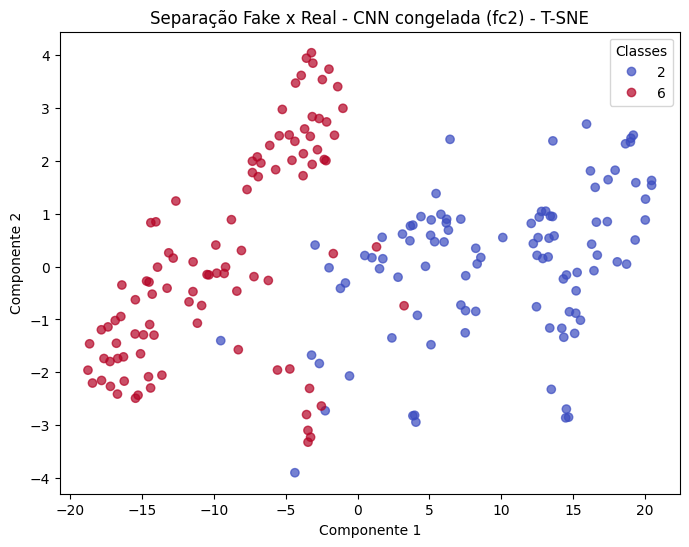

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from PIL import Image
from torch.utils.data import Subset
import cv2
from google.colab import drive
import torch.nn as nn
import torch.nn.functional as F

# 1) Montar o Google Drive
drive.mount('/content/drive', force_remount=True)

# 2) Caminhos das pastas de imagem
BASE_PATH = '/content/drive/MyDrive/dataset/real_fake'
FAKES_FOLDER = 'faces_fake_completada'
REALS_FOLDER = 'faces_real_completada'

# 3) Caminho do arquivo .pth
PTH_PATH = '/content/drive/MyDrive/dataset/pesocongelado/faces_mlp_congelado.pth'

# 4) Loader OpenCV (tons de cinza)
def opencv_loader(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # 1 canal
    return Image.fromarray(img)

# 5) Transform — AGORA 28x28
transform = transforms.Compose([
    transforms.Resize((28, 28)),                   # <<< tamanho ajustado
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 6) Dataset binário (fake x real)
full_dataset = datasets.ImageFolder(
    root=BASE_PATH,
    transform=transform,
    loader=opencv_loader
)

indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in [FAKES_FOLDER, REALS_FOLDER]
]

binary_ds = Subset(full_dataset, indices)

print("Classes:", full_dataset.classes)
print("Total de imagens usadas:", len(binary_ds))

# 7) Rede compatível com o state_dict
class FrozenCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        # conforme o seu state_dict: fc1.weight [120, 256]
        self.fc1 = nn.Linear(16 * 4 * 4, 120)   # 16*4*4 = 256
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # -> [B, 6, 12, 12]
        x = self.pool(F.relu(self.conv2(x)))    # -> [B, 16, 4, 4]
        x = x.view(x.size(0), -1)               # -> [B, 256]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrozenCNN().to(DEVICE)

# 8) Carregar pesos
state = torch.load(PTH_PATH, map_location=DEVICE)
missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
print("Pesos carregados no modelo FrozenCNN.")

model.eval()

# 9) Extrair features da fc2
def extract_features(dataset, model, device):
    features, labels = [], []

    with torch.no_grad():
        for img, label in dataset:
            img = img.unsqueeze(0).to(device)   # [1, 1, 28, 28]
            x = model.pool(F.relu(model.conv1(img)))
            x = model.pool(F.relu(model.conv2(x)))
            x = x.view(x.size(0), -1)
            x = F.relu(model.fc1(x))
            x = F.relu(model.fc2(x))           # [1, 84]
            features.append(x.cpu().numpy())
            labels.append(label)

    return np.concatenate(features), np.array(labels)

features, labels = extract_features(binary_ds, model, DEVICE)
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# 10) T-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(features)

# 11) Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels, cmap='coolwarm', alpha=0.7
)
plt.title("Separação Fake x Real - CNN congelada (fc2) - T-SNE")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()
